In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
# Load and combine generation + consumption data for each scenario
actual_electricity_data = {}

# Define rename map for generation carriers
rename_map = {
    'Biomass': 'biomass', 'Hydropower': 'hydro', 'Wind offshore': 'offwind-ac',
    'Wind onshore': 'onwind', 'Photovoltaics': 'solar', 'Other renewable': 'waste',
    'Nuclear': 'nuclear', 'Lignite': 'lignite', 'Hard coal': 'coal',
    'Fossil gas': 'gas', 'Hydro pumped storage': 'hydro', 'Other conventional': 'oil'
}

real_data_paths = {
    "Windy": {
        "generation": "/home/lucakristin/Desktop/my_pypsa/actual_electricity_data/Actual_generation_202510260000_202510270000_Hour.csv",
        "consumption": "/home/lucakristin/Desktop/my_pypsa/actual_electricity_data/Actual_consumption_202510260000_202510270000_Hour_2.csv"
    },
    "Not Windy": {
        "generation": "/home/lucakristin/Desktop/my_pypsa/actual_electricity_data/Actual_generation_202504080000_202504090000_Hour.csv",
        "consumption": "/home/lucakristin/Desktop/my_pypsa/actual_electricity_data/Actual_consumption_202504080000_202504090000_Hour_2.csv"
    },
    "Wind Variability": {
        "generation": "/home/lucakristin/Desktop/my_pypsa/actual_electricity_data/Actual_generation_202510060000_202510070000_Hour.csv",
        "consumption": "/home/lucakristin/Desktop/my_pypsa/actual_electricity_data/Actual_consumption_202510060000_202510070000_Hour_2.csv"
    }
}

for scenario_title, paths in real_data_paths.items():
    # --- Load Generation Data ---
    gen_df = pd.read_csv(paths["generation"], sep=';', thousands=',', na_values=['-'])
    gen_df['Start date'] = pd.to_datetime(gen_df['Start date'], format='mixed')
    gen_df = gen_df.set_index('Start date')
    gen_df = gen_df.drop('End date', axis=1)
    
    # Clean column names
    gen_df.columns = [c.replace(' [MWh] Calculated resolutions', '') for c in gen_df.columns]
    
    # Apply rename map to generation carriers
    gen_df = gen_df.rename(columns=rename_map)
    
    # Aggregate duplicate column names (e.g., "hydro" appears twice)
    gen_df = gen_df.T.groupby(level=0).sum().T
    
    # --- Load Consumption Data ---
    cons_df = pd.read_csv(paths["consumption"], sep=';', thousands=',', decimal='.')
    
    # Find the date column
    date_col_candidates = [c for c in cons_df.columns if 'date' in c.lower()]
    date_col = date_col_candidates[0] if date_col_candidates else cons_df.columns[0]
    
    cons_df['time'] = pd.to_datetime(cons_df[date_col], format='mixed')
    cons_df = cons_df.set_index('time')
    
    # --- Extract all consumption columns (excluding dates) ---
    # Drop date-related columns and keep all others
    consumption_cols = [c for c in cons_df.columns if 'date' not in c.lower() and 'end date' not in c.lower()]
    consumption_data = cons_df[consumption_cols]
    
    # Keep only the two load-related columns and rename them for plotting
    load_col_map = {
        'grid load [MWh] Calculated resolutions': 'grid load',
        'Grid load incl. hydro pumped storage [MWh] Calculated resolutions': 'grid load with hydro storage',
    }
    consumption_data = cons_df[list(load_col_map)].rename(columns=load_col_map)
    consumption_data = consumption_data.apply(pd.to_numeric, errors='coerce').fillna(0)
    
    # --- Combine Generation + Consumption Columns ---
    combined_df = pd.concat([gen_df, consumption_data], axis=1)
    
    # Store in dictionary
    actual_electricity_data[scenario_title] = combined_df

    # export to CSV for later use
    combined_df.to_csv(f"/home/lucakristin/Desktop/my_pypsa/actual_electricity_data/combined_{scenario_title.replace(' ', '_').lower()}.csv")

In [6]:
carrier_display_names = {
    "onwind": "Onshore wind",
    "offwind-ac": "Offshore wind (AC)",
    "offwind-float": "Offshore wind (floating)",
    "solar": "Solar PV",
    "solar-hsat": "Solar PV (high satellite)",
    "hydro": "Hydro",
    "ror": "Run-of-river",
    "lignite": "Lignite",
    "coal": "Coal",
    "oil": "Oil",
    "OCGT": "OCGT",
    "CCGT": "CCGT",
    "biomass": "Biomass",
    "waste": "Waste",
    "geothermal": "Geothermal",
    "load": "Unserved Load",
    "battery discharge": "Battery discharge",
}

def carrier_label(name):
    return carrier_display_names.get(name, name)

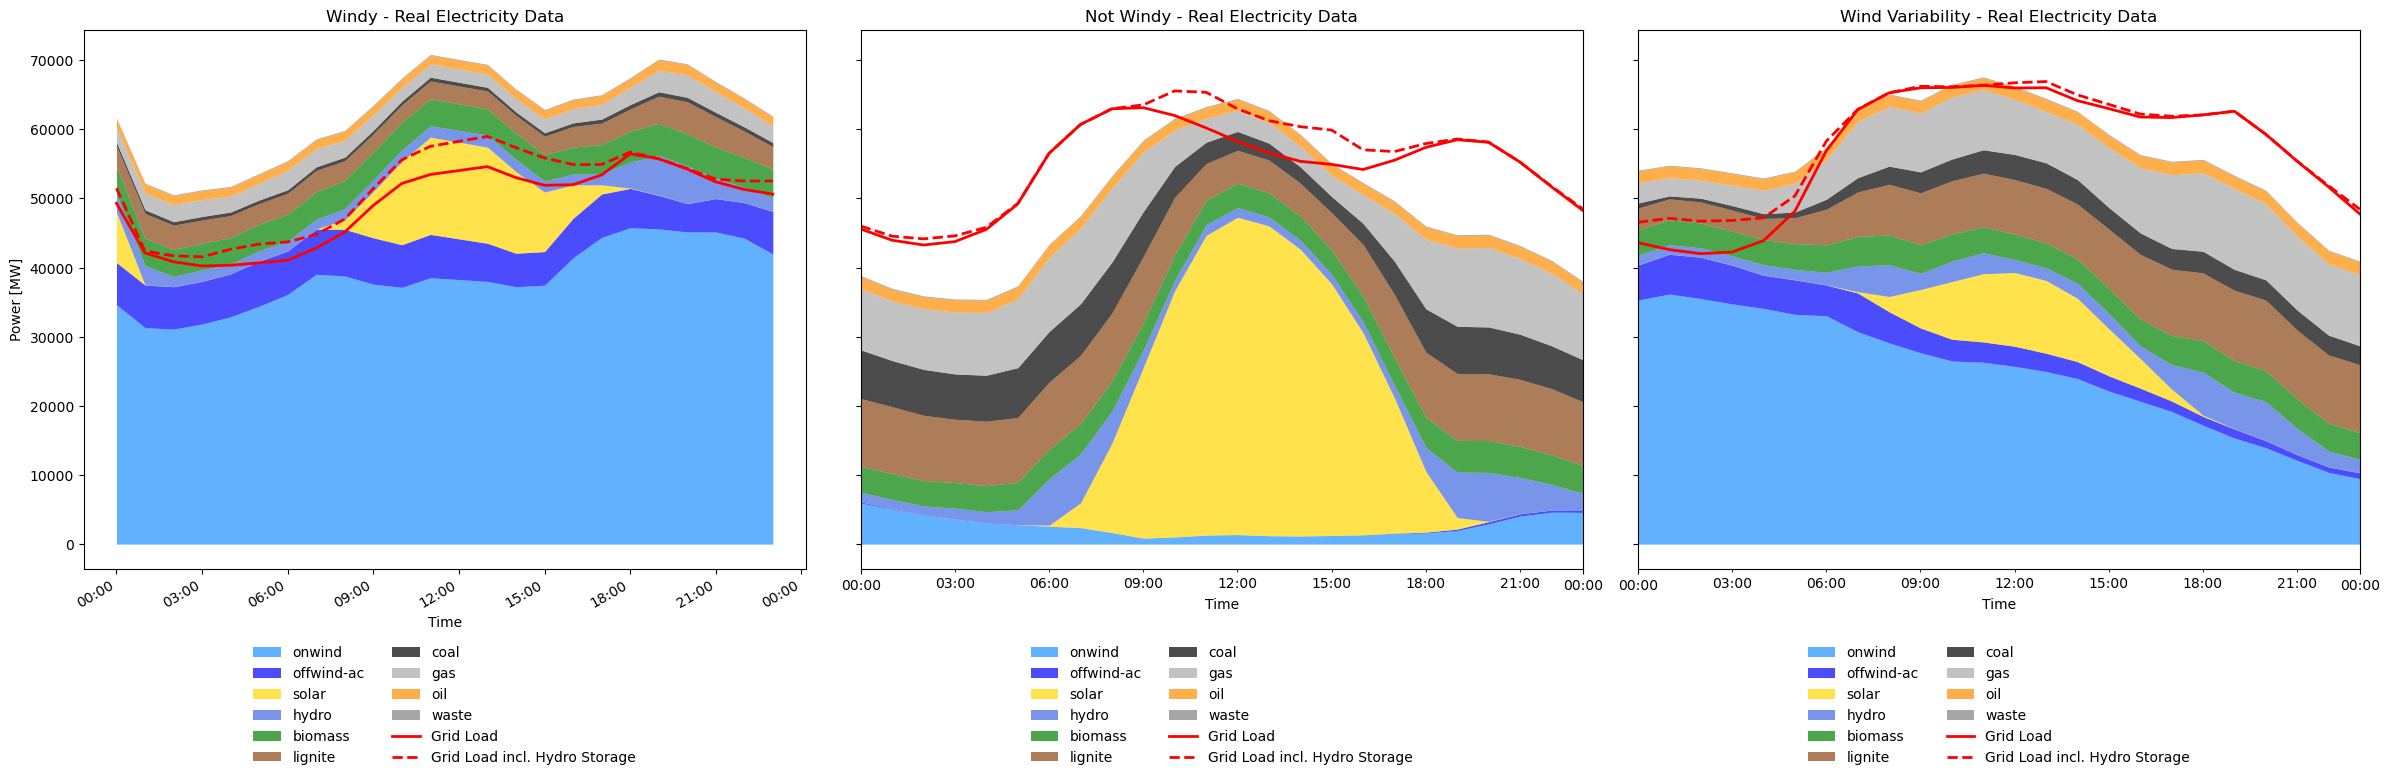

In [13]:
# Plot the combined real-data frames for comparison with the simulation
fig, axes = plt.subplots(1, 3, figsize=(24, 7), sharey=True)

colors = {
   # Wind
    "onwind": "dodgerblue",
    "offwind-ac": "blue",
    "offwind-float": "steelblue",
    # Solar
    "solar": "gold",
    "solar-hsat": "khaki",
    # Hydro
    "hydro": "royalblue",
    "ror": "lightblue",
    # Fossil Fuels
    "lignite": "saddlebrown",
    "coal": "black",
    "gas": "darkgray",
    "oil": "darkorange",
    # Other
    "biomass": "green",
    "geothermal": "firebrick",
    "battery discharge": "purple",
}

cols = [
    "onwind", "offwind-ac", "offwind-float",
    "solar", "solar-hsat",
    "hydro", "ror",
    "biomass", "geothermal",
    "lignite", "coal", "gas", "oil", "waste",
    "OCGT", "CCGT",
    "battery discharge",
    "load",
]

scenario_titles = ["Windy", "Not Windy", "Wind Variability"]

for ax, scenario_title in zip(axes, scenario_titles):
    df = actual_electricity_data[scenario_title].copy().sort_index()

    if df.index.duplicated().any():
        df = df.groupby(level=0).mean(numeric_only=True)

    generation_cols = [col for col in cols if col in df.columns]
    plot_df = df[generation_cols].copy()
    plot_colors = [colors.get(col, "gray") for col in generation_cols]

    plot_df.plot(kind="area", ax=ax, lw=0, color=plot_colors, alpha=0.7)

    if "grid load" in df.columns:
        df["grid load"].plot(ax=ax, color="red", lw=2, label="Grid Load")
    if "grid load with hydro storage" in df.columns:
        df["grid load with hydro storage"].plot(
            ax=ax,
            color="red",
            lw=2,
            linestyle="--",
            label="Grid Load incl. Hydro Storage",
        )

    ax.set_title(f"{scenario_title} - Real Electricity Data")
    ax.set_ylabel("Power [MW]")
    ax.set_xlabel("Time")
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%H:%M"))
    ax.legend(ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.12), frameon=False)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.show()

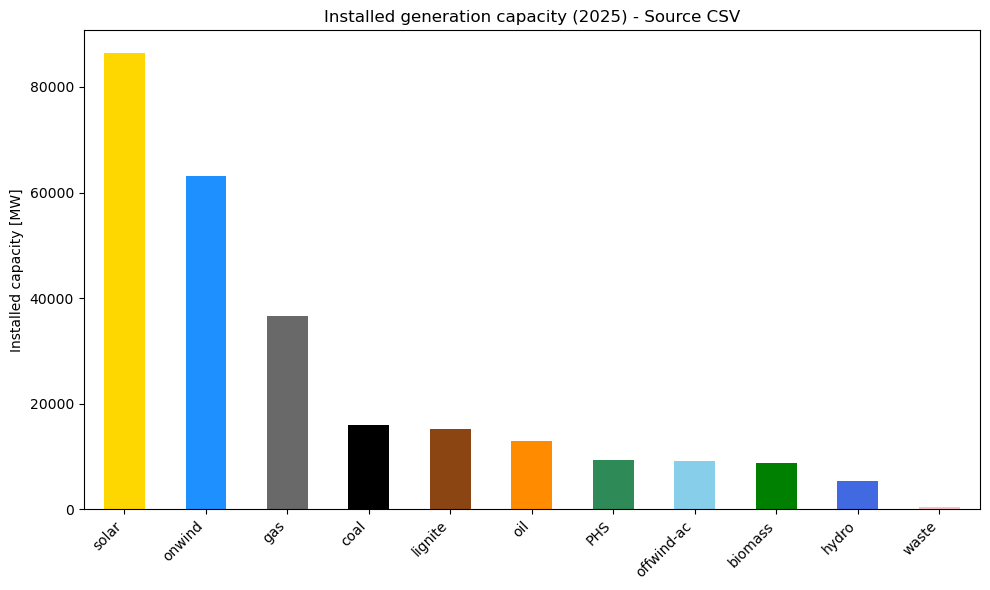

Total installed capacity (CSV): 263475.0
solar         86408.0
onwind        63192.0
gas           36614.0
coal          15951.0
lignite       15178.0
oil           12971.0
PHS            9384.0
offwind-ac     9215.0
biomass        8766.0
hydro          5350.0
waste           446.0


In [10]:
# Plot installed capacities from CSV
import numpy as np
installed_capacity_path = "/home/lucakristin/Desktop/my_pypsa/actual_electricity_data/Installed_generation_capacity_202305130000_202505130000_Year.csv"

# Read CSV
df_inst = pd.read_csv(installed_capacity_path, sep=';')
if df_inst.empty:
    raise ValueError(f"No data in {installed_capacity_path}")
row = df_inst.iloc[0]

# Map CSV columns to carrier keys
graphic_map = {
    'Biomass [MW] Original resolutions': 'biomass',
    'Hydropower [MW] Original resolutions': 'hydro',
    'Wind offshore [MW] Original resolutions': 'offwind-ac',
    'Wind onshore [MW] Original resolutions': 'onwind',
    'Photovoltaics [MW] Original resolutions': 'solar',
    'Other renewable [MW] Original resolutions': 'waste',
    'Nuclear [MW] Original resolutions': 'nuclear',
    'Lignite [MW] Original resolutions': 'lignite',
    'Hard coal [MW] Original resolutions': 'coal',
    'Fossil gas [MW] Original resolutions': 'gas',
    'Hydro pumped storage [MW] Original resolutions': 'PHS',
    'Other conventional [MW] Original resolutions': 'oil',
}

data = {}
for src, dest in graphic_map.items():
    if src in row.index:
        v = row[src]
        if pd.isna(v):
            continue
        # Remove thousands separators and convert
        if isinstance(v, str):
            v = v.replace(',', '')
        try:
            data[dest] = float(v)
        except Exception:
            continue

series = pd.Series(data).sort_values(ascending=False)

# Colors
colors = {
    'onwind': 'dodgerblue', 'offwind-ac': 'skyblue', 'offwind-float': 'steelblue',
    'solar': 'gold', 'solar-hsat': 'khaki',
    'hydro': 'royalblue', 'ror': 'lightblue',
    'lignite': 'saddlebrown', 'coal': 'black', 'gas': 'dimgray', 'oil': 'darkorange',
    'OCGT': 'lightgray', 'CCGT': 'darkgray',
    'biomass': 'green', 'waste': 'pink', 'geothermal': 'firebrick', 'PHS': 'seagreen', 'nuclear': 'purple'
}
bar_colors = [colors.get(c, 'gray') for c in series.index]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
series.plot(kind='bar', color=bar_colors, ax=ax)
ax.set_ylabel('Installed capacity [MW]')
ax.set_title('Installed generation capacity (2025) - Source CSV')
ax.set_xticklabels(series.index, rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print summary
print('Total installed capacity (CSV):', series.sum())
print(series.to_string())
